# Deconvolve Chromatin Bins for CLB2

In this notebook, we will be refactoring the creation of the H matrix for the RG1 model. For Yulong's dataset, we have alpha factor arrested cells that go through recovery. We want this recovery period to incorporate the first G1, so the initial branch will be: Recovery - postG1. The calcH needs to be updated to reflect that change.

Goal:
- Refactor the creation of the H matrix
- We need to make changes to add the RG1 logic (merge R and G1 for the first c for {0, 0}

Steps:
1. Plot the growth curve to better understand the existing calc H function

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


findOptimal
  ... base_rn = 0.0051
  ... gamma in [0.0001, 0.0040]
  ...  search left, rn_goal = 0.0056, rate = 10.0
  ...  search right, rn_goal = 0.3251, rate = 6314.2
  ... rn range: [0.0131, 0.1062]
  ... search gamma in [0.0001 0.0040] for elbow
  ...   gamma = 0.0001, rn = 0.01312, sn = 64.72
  ...   gamma = 0.00049, rn = 0.03429, sn = 30.11
  ...   gamma = 0.00088, rn = 0.05245, sn = 24.18
  ...   gamma = 0.00127, rn = 0.05633, sn = 22.73
  ...   gamma = 0.00166, rn = 0.06194, sn = 20.84
  ...   gamma = 0.00205, rn = 0.06752, sn = 19.2
  ...   gamma = 0.00244, rn = 0.07308, sn = 17.93
  ...   gamma = 0.00283, rn = 0.08067, sn = 16.25
  ...   gamma = 0.00322, rn = 0.08927, sn = 14.32
  ...   gamma = 0.00361, rn = 0.09771, sn = 12.73
  ...   gamma = 0.004, rn = 0.1062, sn = 11.25
The x_grad1 is: [0.02117087 0.0196682  0.01101978 0.00474416 0.00559791 0.00557018
 0.00657191 0.00809329 0.00852102 0.00848741 0.0085344 ]
The x_grad2 is: [-1.50266974e-03 -5.07554586e-03 -7.46201978e-03

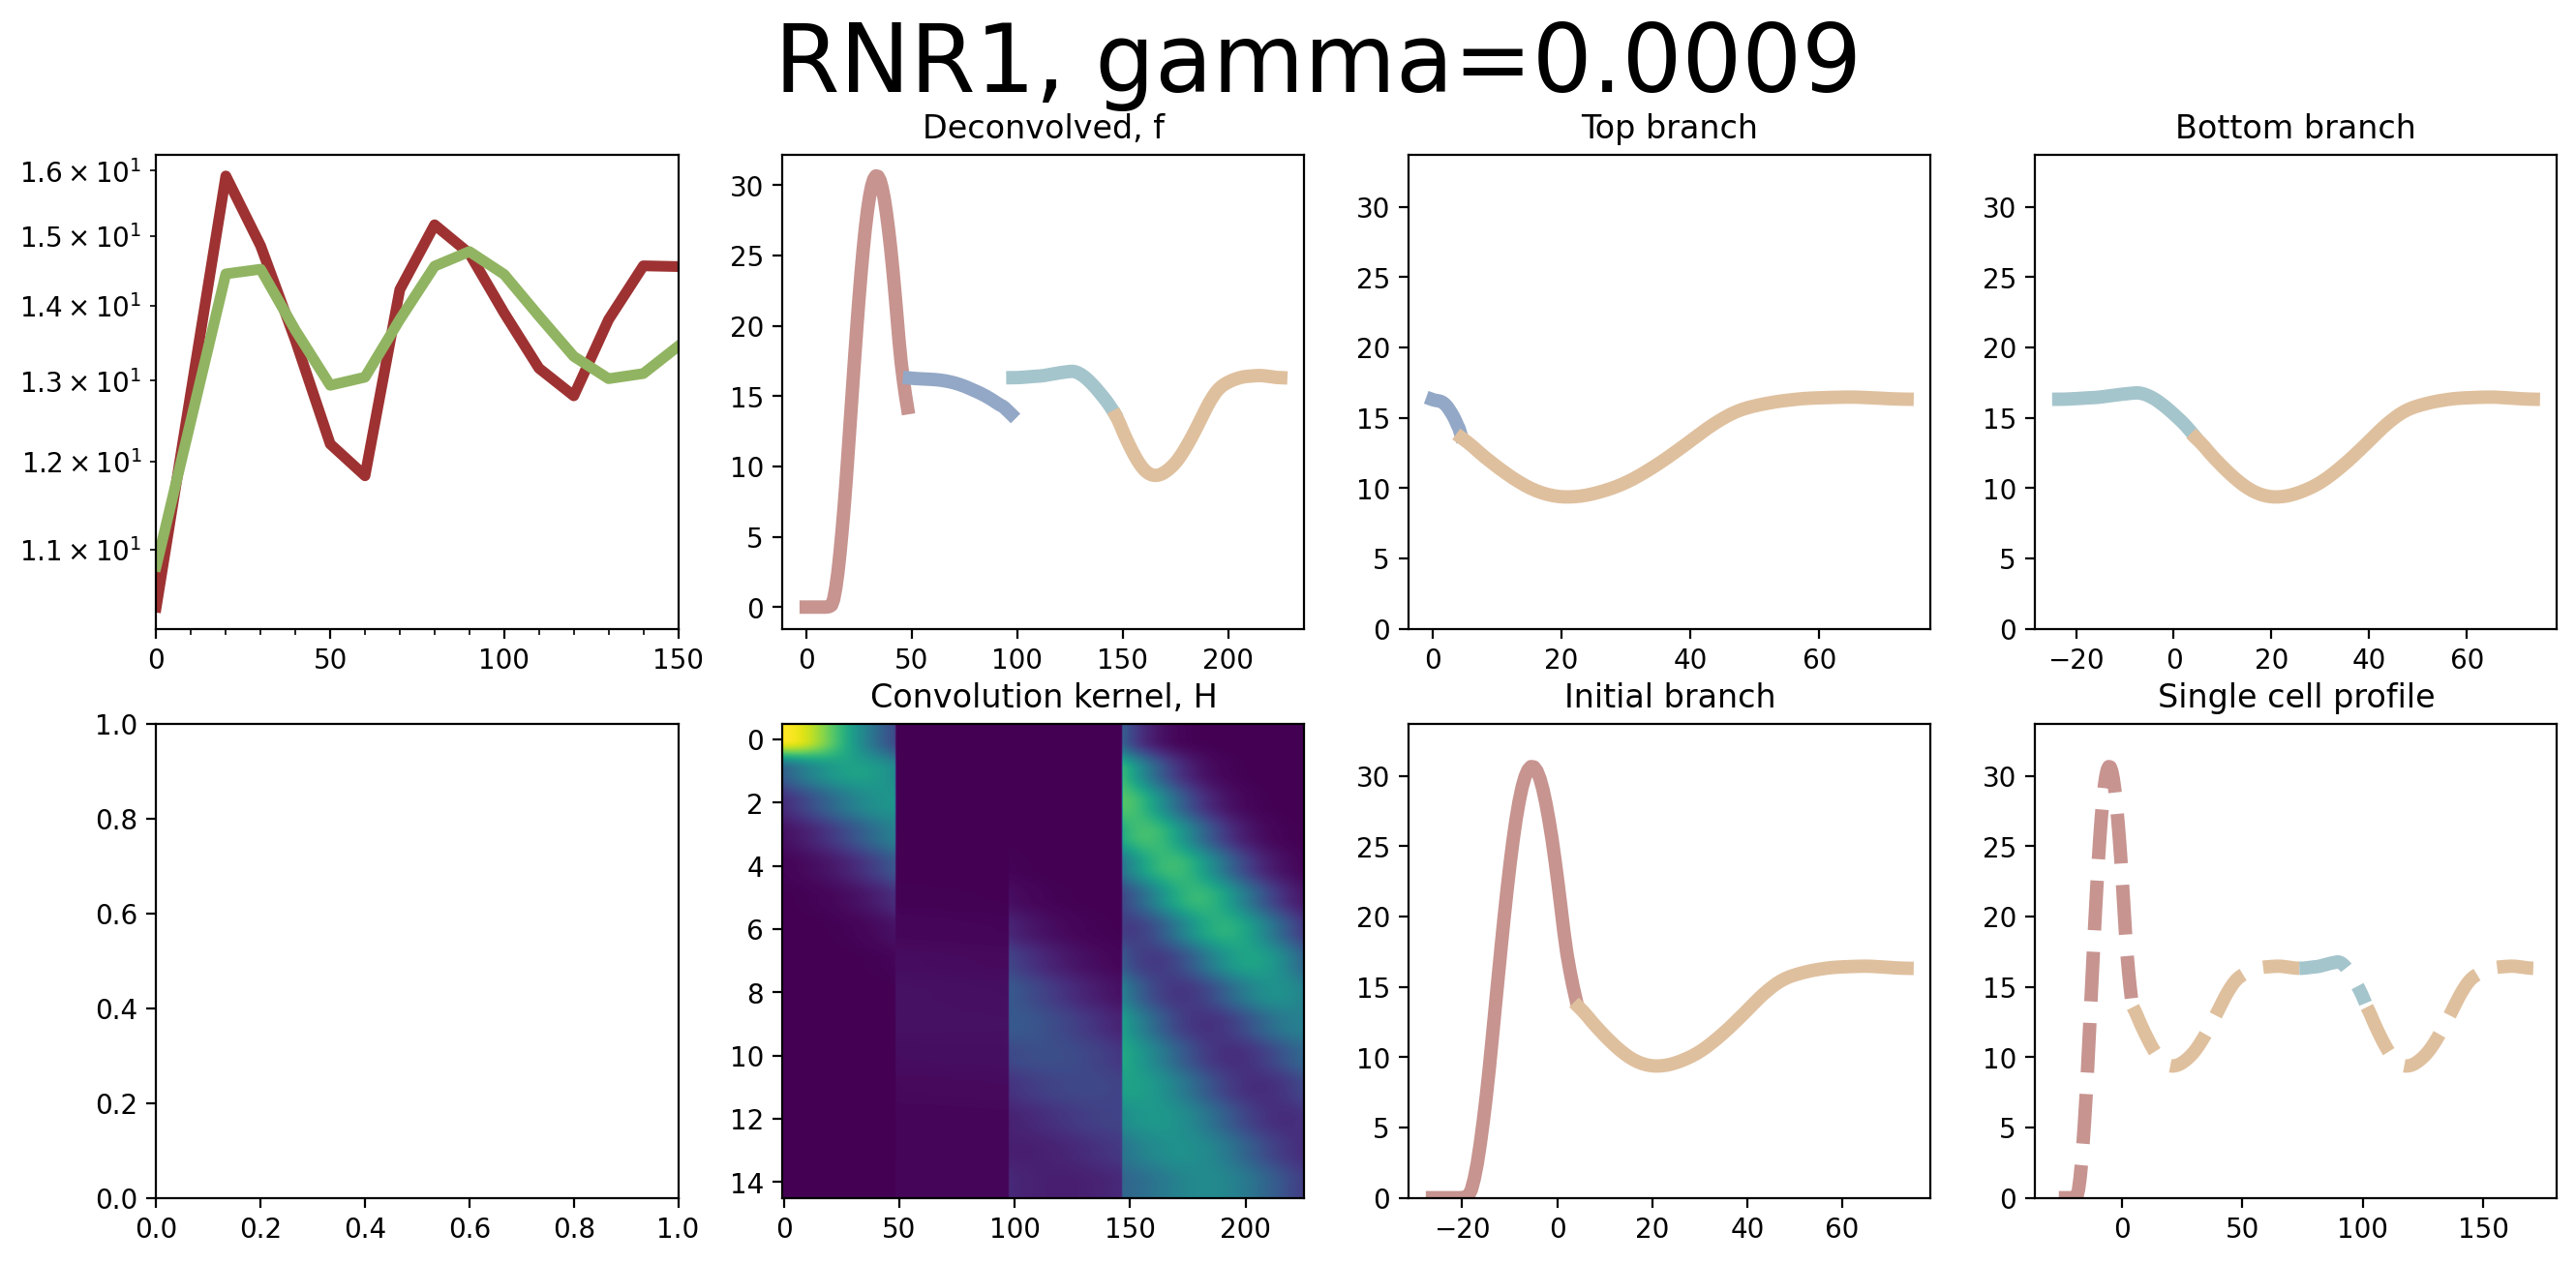

In [25]:
from src.config import load_yl_replicate1_rg1_vst_config, load_yl_replicate2_rg1_vst_config, \
    load_combined_yl_vst_gene_expression_config
from src.model import Model

vst_config = load_yl_replicate1_rg1_vst_config()
vst_model = Model(config=vst_config, gamma=0.0002, gene_or_orfname='RNR1')

try:
    find_gamma = FindOptimalGamma(vst_model)
    find_gamma.find_optimal()
except UnboundLocalError:
    vst_model.deconvolve()

vst_model.plot_deconvolved_gene()

findOptimal
  ... base_rn = 0.0083
  ... gamma in [0.0001, 0.0040]
  ...  search left, rn_goal = 0.0091, rate = 10.0
  ...  search right, rn_goal = 0.3283, rate = 3853.3
  ... rn range: [0.0180, 0.0760]
  ... search gamma in [0.0001 0.0040] for elbow
  ...   gamma = 0.0001, rn = 0.01797, sn = 58.11
  ...   gamma = 0.00049, rn = 0.03193, sn = 33.6
  ...   gamma = 0.00088, rn = 0.04283, sn = 23.89
  ...   gamma = 0.00127, rn = 0.04825, sn = 20.61
  ...   gamma = 0.00166, rn = 0.05343, sn = 18.4
  ...   gamma = 0.00205, rn = 0.05791, sn = 17.3
  ...   gamma = 0.00244, rn = 0.06053, sn = 16.65
  ...   gamma = 0.00283, rn = 0.06151, sn = 16.48
  ...   gamma = 0.00322, rn = 0.06375, sn = 16.07
  ...   gamma = 0.00361, rn = 0.06936, sn = 14.8
  ...   gamma = 0.004, rn = 0.07603, sn = 13.52
The x_grad1 is: [0.01396622 0.01243015 0.00815704 0.0053025  0.00483037 0.00354886
 0.00180346 0.00161004 0.00392199 0.00613897 0.00666911]
The x_grad2 is: [-0.00153607 -0.00290459 -0.00356383 -0.00166334 -

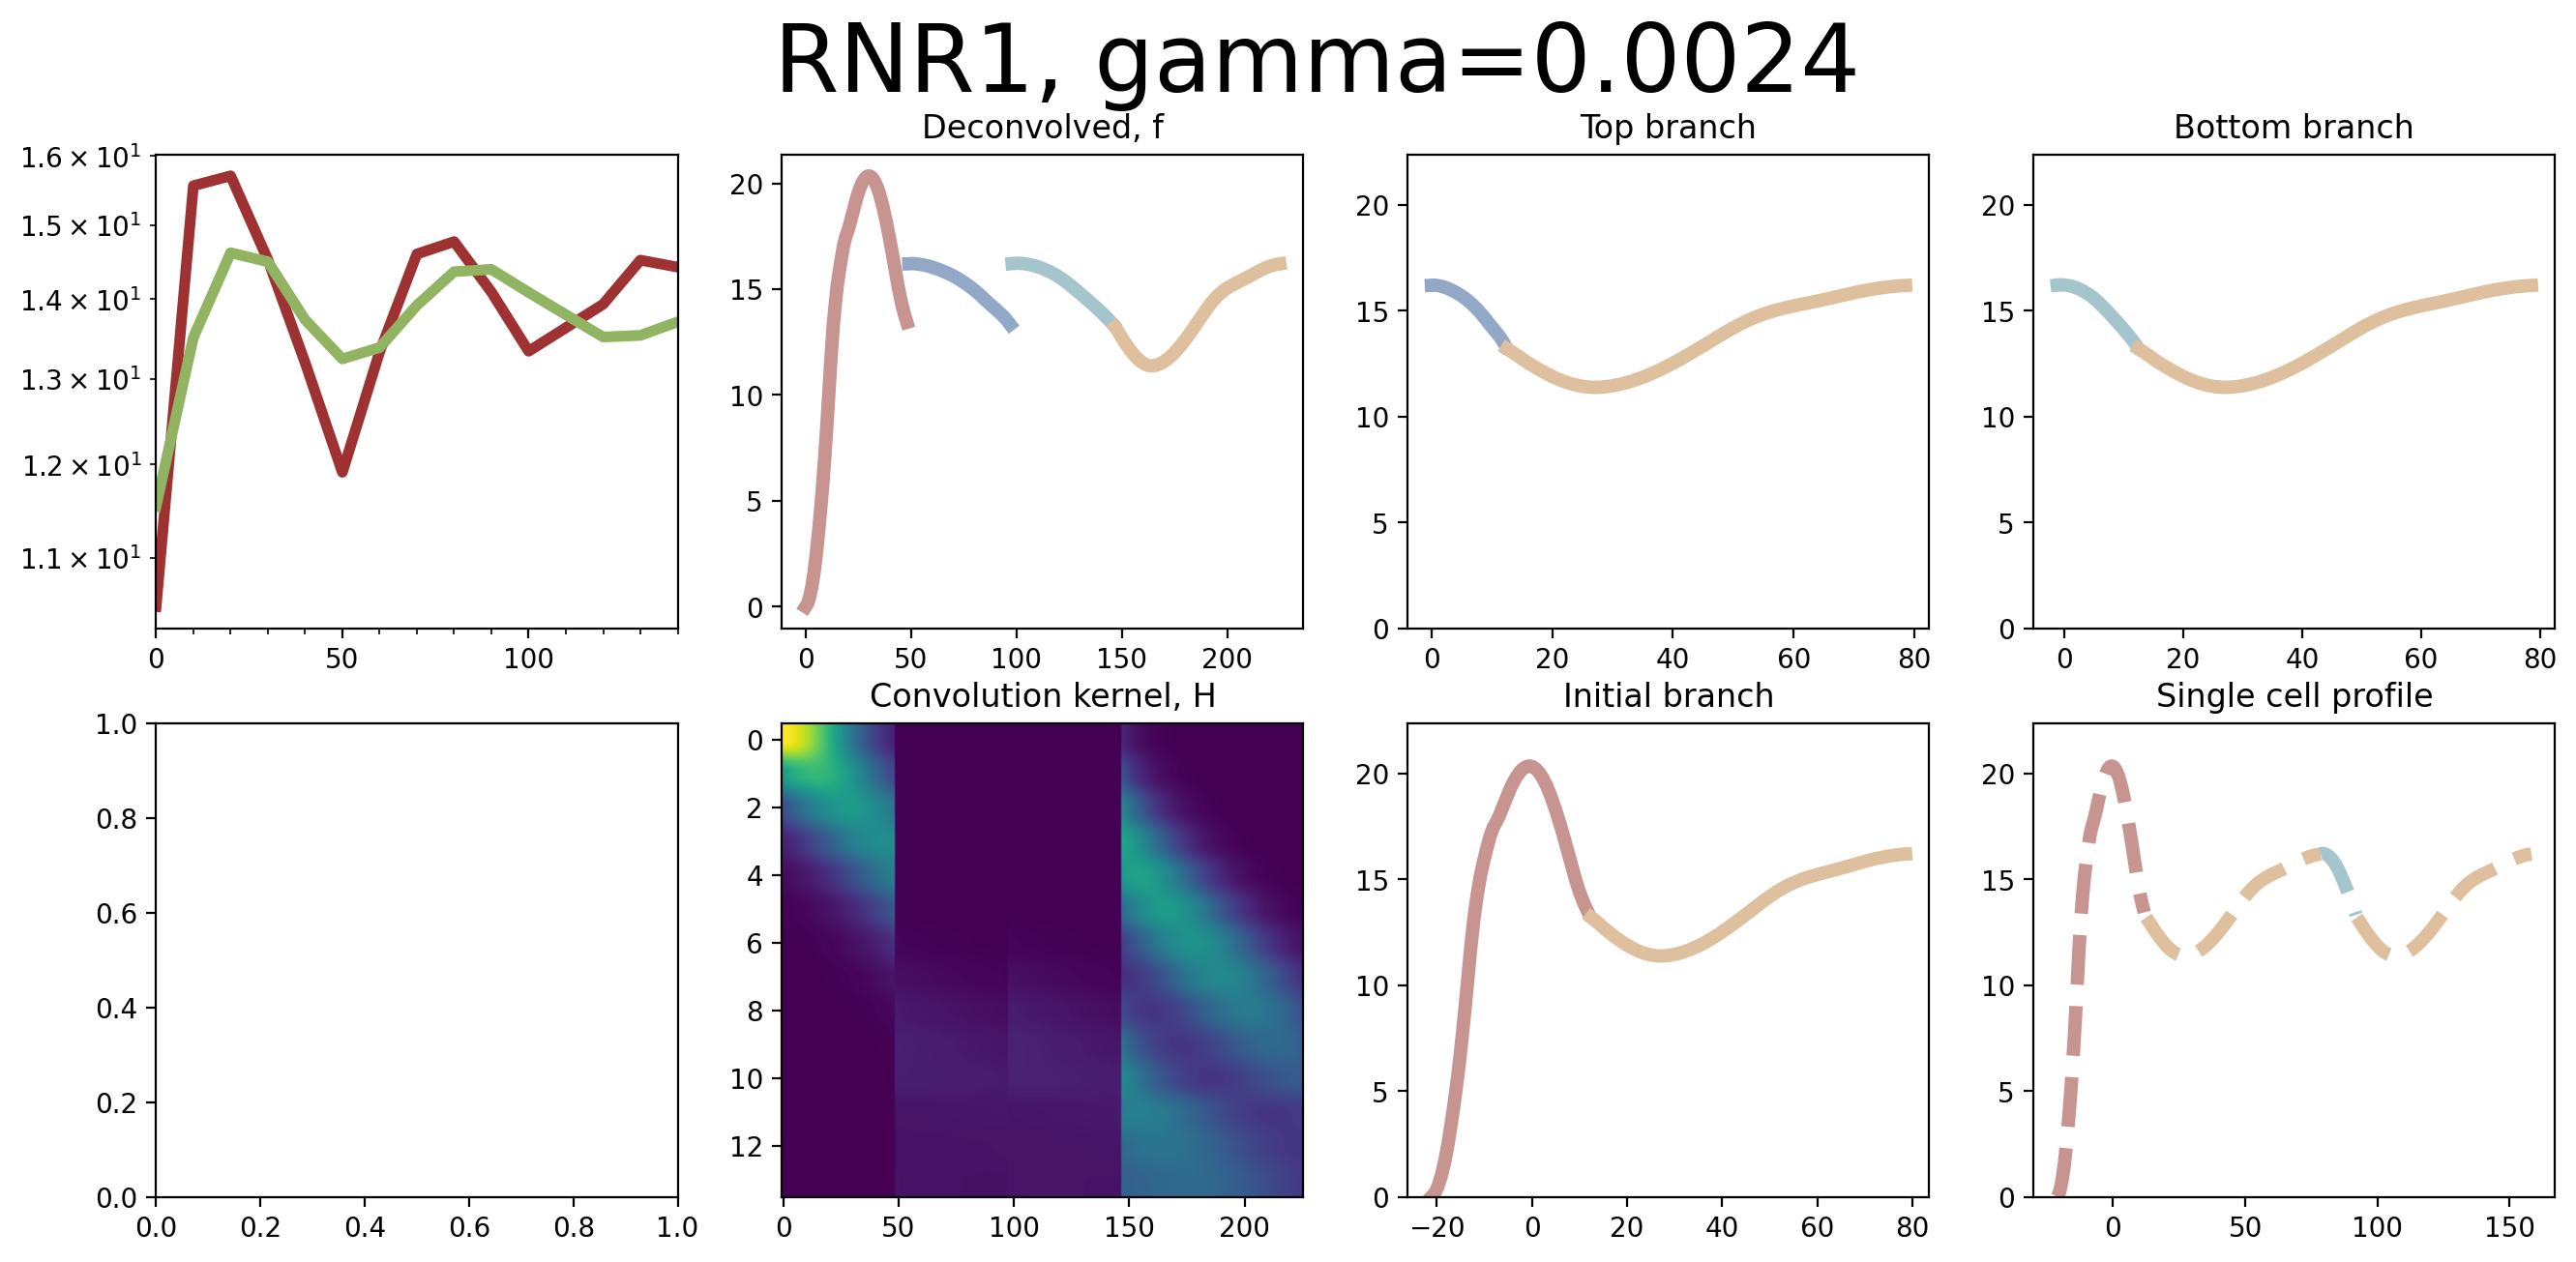

In [26]:
vst_config = load_yl_replicate2_rg1_vst_config()
vst_model = Model(config=vst_config, gamma=0.0002, gene_or_orfname='RNR1')

try:
    find_gamma = FindOptimalGamma(vst_model)
    find_gamma.find_optimal()
except UnboundLocalError:
    vst_model.deconvolve()

vst_model.plot_deconvolved_gene()

findOptimal
  ... base_rn = 0.0659
  ... gamma in [0.0001, 0.0040]
  ...  search left, rn_goal = 0.0725, rate = 10.0
  ...  search right, rn_goal = 0.3859, rate = 485.3
  ... rn range: [0.0810, 0.1454]
  ... search gamma in [0.0001 0.0040] for elbow
  ...   gamma = 0.0001, rn = 0.08102, sn = 60.4
  ...   gamma = 0.00049, rn = 0.09994, sn = 33.51
  ...   gamma = 0.00088, rn = 0.1136, sn = 24.68
  ...   gamma = 0.00127, rn = 0.1213, sn = 22.15
  ...   gamma = 0.00166, rn = 0.1246, sn = 21.23
  ...   gamma = 0.00205, rn = 0.1297, sn = 20.21
  ...   gamma = 0.00244, rn = 0.1333, sn = 19.52
  ...   gamma = 0.00283, rn = 0.1354, sn = 19.09
  ...   gamma = 0.00322, rn = 0.1379, sn = 18.62
  ...   gamma = 0.00361, rn = 0.1417, sn = 17.99
  ...   gamma = 0.004, rn = 0.1454, sn = 17.36
The x_grad1 is: [0.01891745 0.01628279 0.01070341 0.00549844 0.00419881 0.00433912
 0.0028327  0.00232823 0.00315634 0.00374057 0.00367831]
The x_grad2 is: [-2.63466272e-03 -4.10701856e-03 -5.39217233e-03 -3.25229

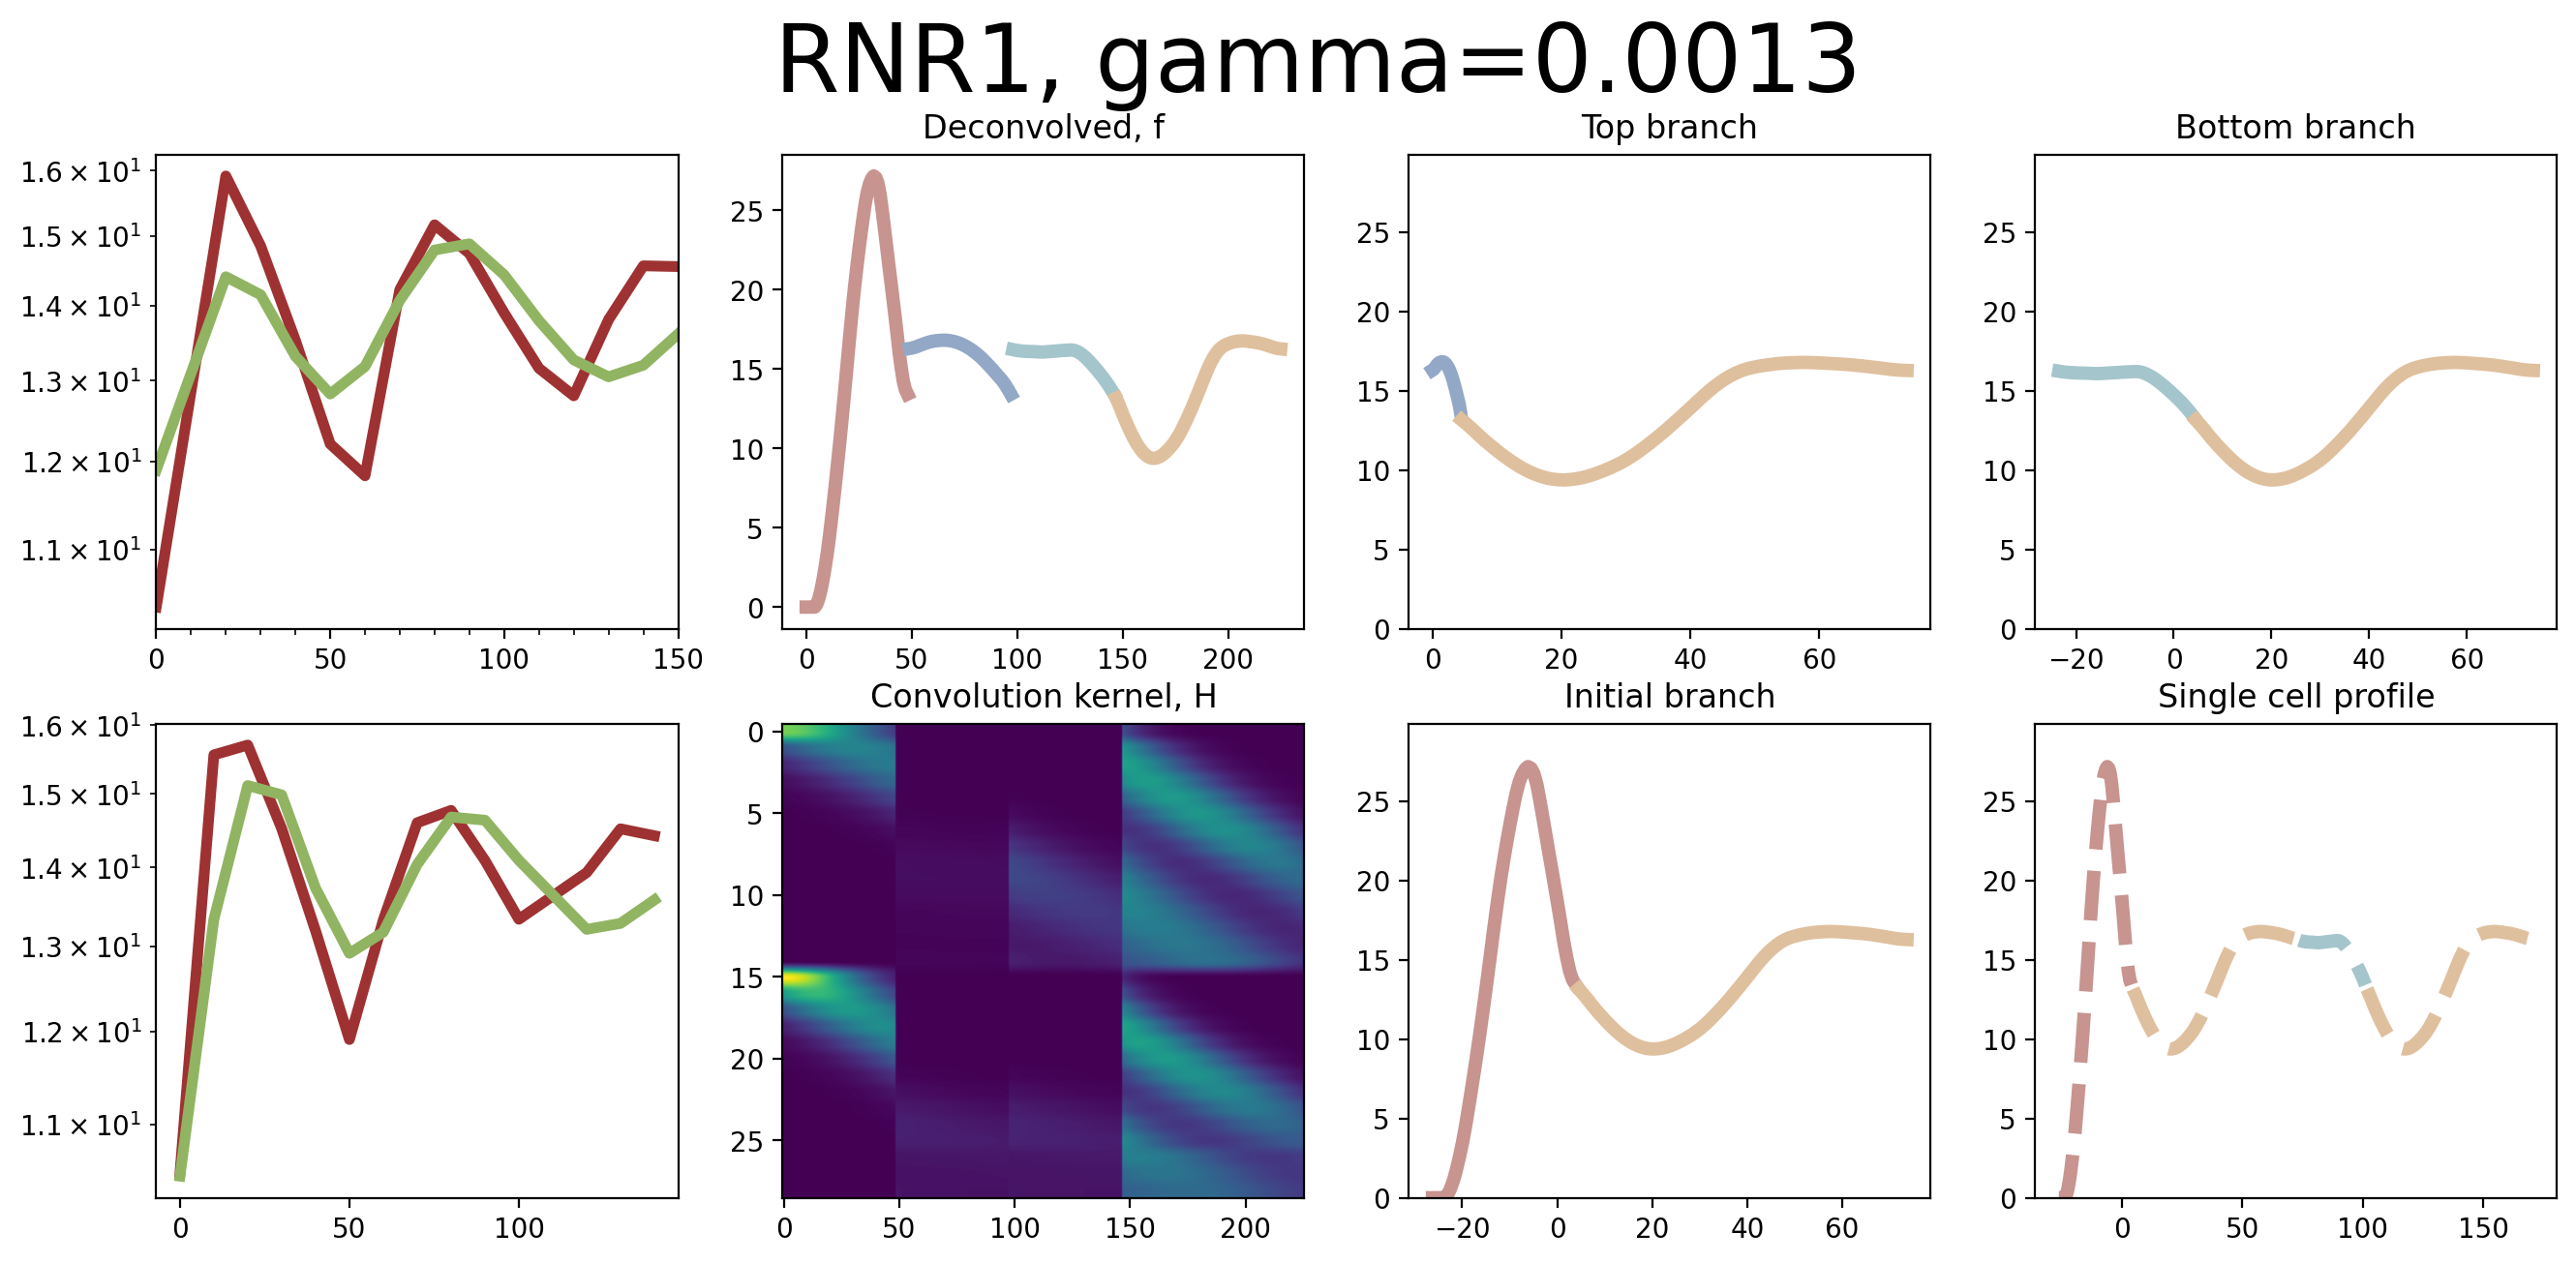

In [27]:
from src.find_gamma import FindOptimalGamma

vst_config = load_combined_yl_vst_gene_expression_config()
vst_model = Model(config=vst_config, gamma=0.001, gene_or_orfname='RNR1')

try:
    find_gamma = FindOptimalGamma(vst_model)
    find_gamma.find_optimal()
except UnboundLocalError:
    vst_model.deconvolve()
          
vst_model.plot_deconvolved_gene()

findOptimal
  ... base_rn = 0.0402
  ... gamma in [0.0001, 0.0040]
  ...  search left, rn_goal = 0.0442, rate = 10.0
  ...  search right, rn_goal = 0.3602, rate = 796.8
  ... rn range: [0.0497, 0.0906]
  ... search gamma in [0.0001 0.0040] for elbow
  ...   gamma = 0.0001, rn = 0.04967, sn = 60.77
  ...   gamma = 0.00049, rn = 0.07346, sn = 9.844
  ...   gamma = 0.00088, rn = 0.07657, sn = 8.937
  ...   gamma = 0.00127, rn = 0.0785, sn = 8.158
  ...   gamma = 0.00166, rn = 0.08043, sn = 7.66
  ...   gamma = 0.00205, rn = 0.08155, sn = 7.511
  ...   gamma = 0.00244, rn = 0.0826, sn = 7.389
  ...   gamma = 0.00283, rn = 0.08388, sn = 7.267
  ...   gamma = 0.00322, rn = 0.08596, sn = 7.181
  ...   gamma = 0.00361, rn = 0.08804, sn = 7.16
  ...   gamma = 0.004, rn = 0.09061, sn = 7.076
The x_grad1 is: [0.02379496 0.01345442 0.00252162 0.00192873 0.0015228  0.00108329
 0.00116367 0.00167874 0.00208126 0.00232817 0.00257303]
The x_grad2 is: [-0.01034054 -0.01063667 -0.00576285 -0.00049941 -0

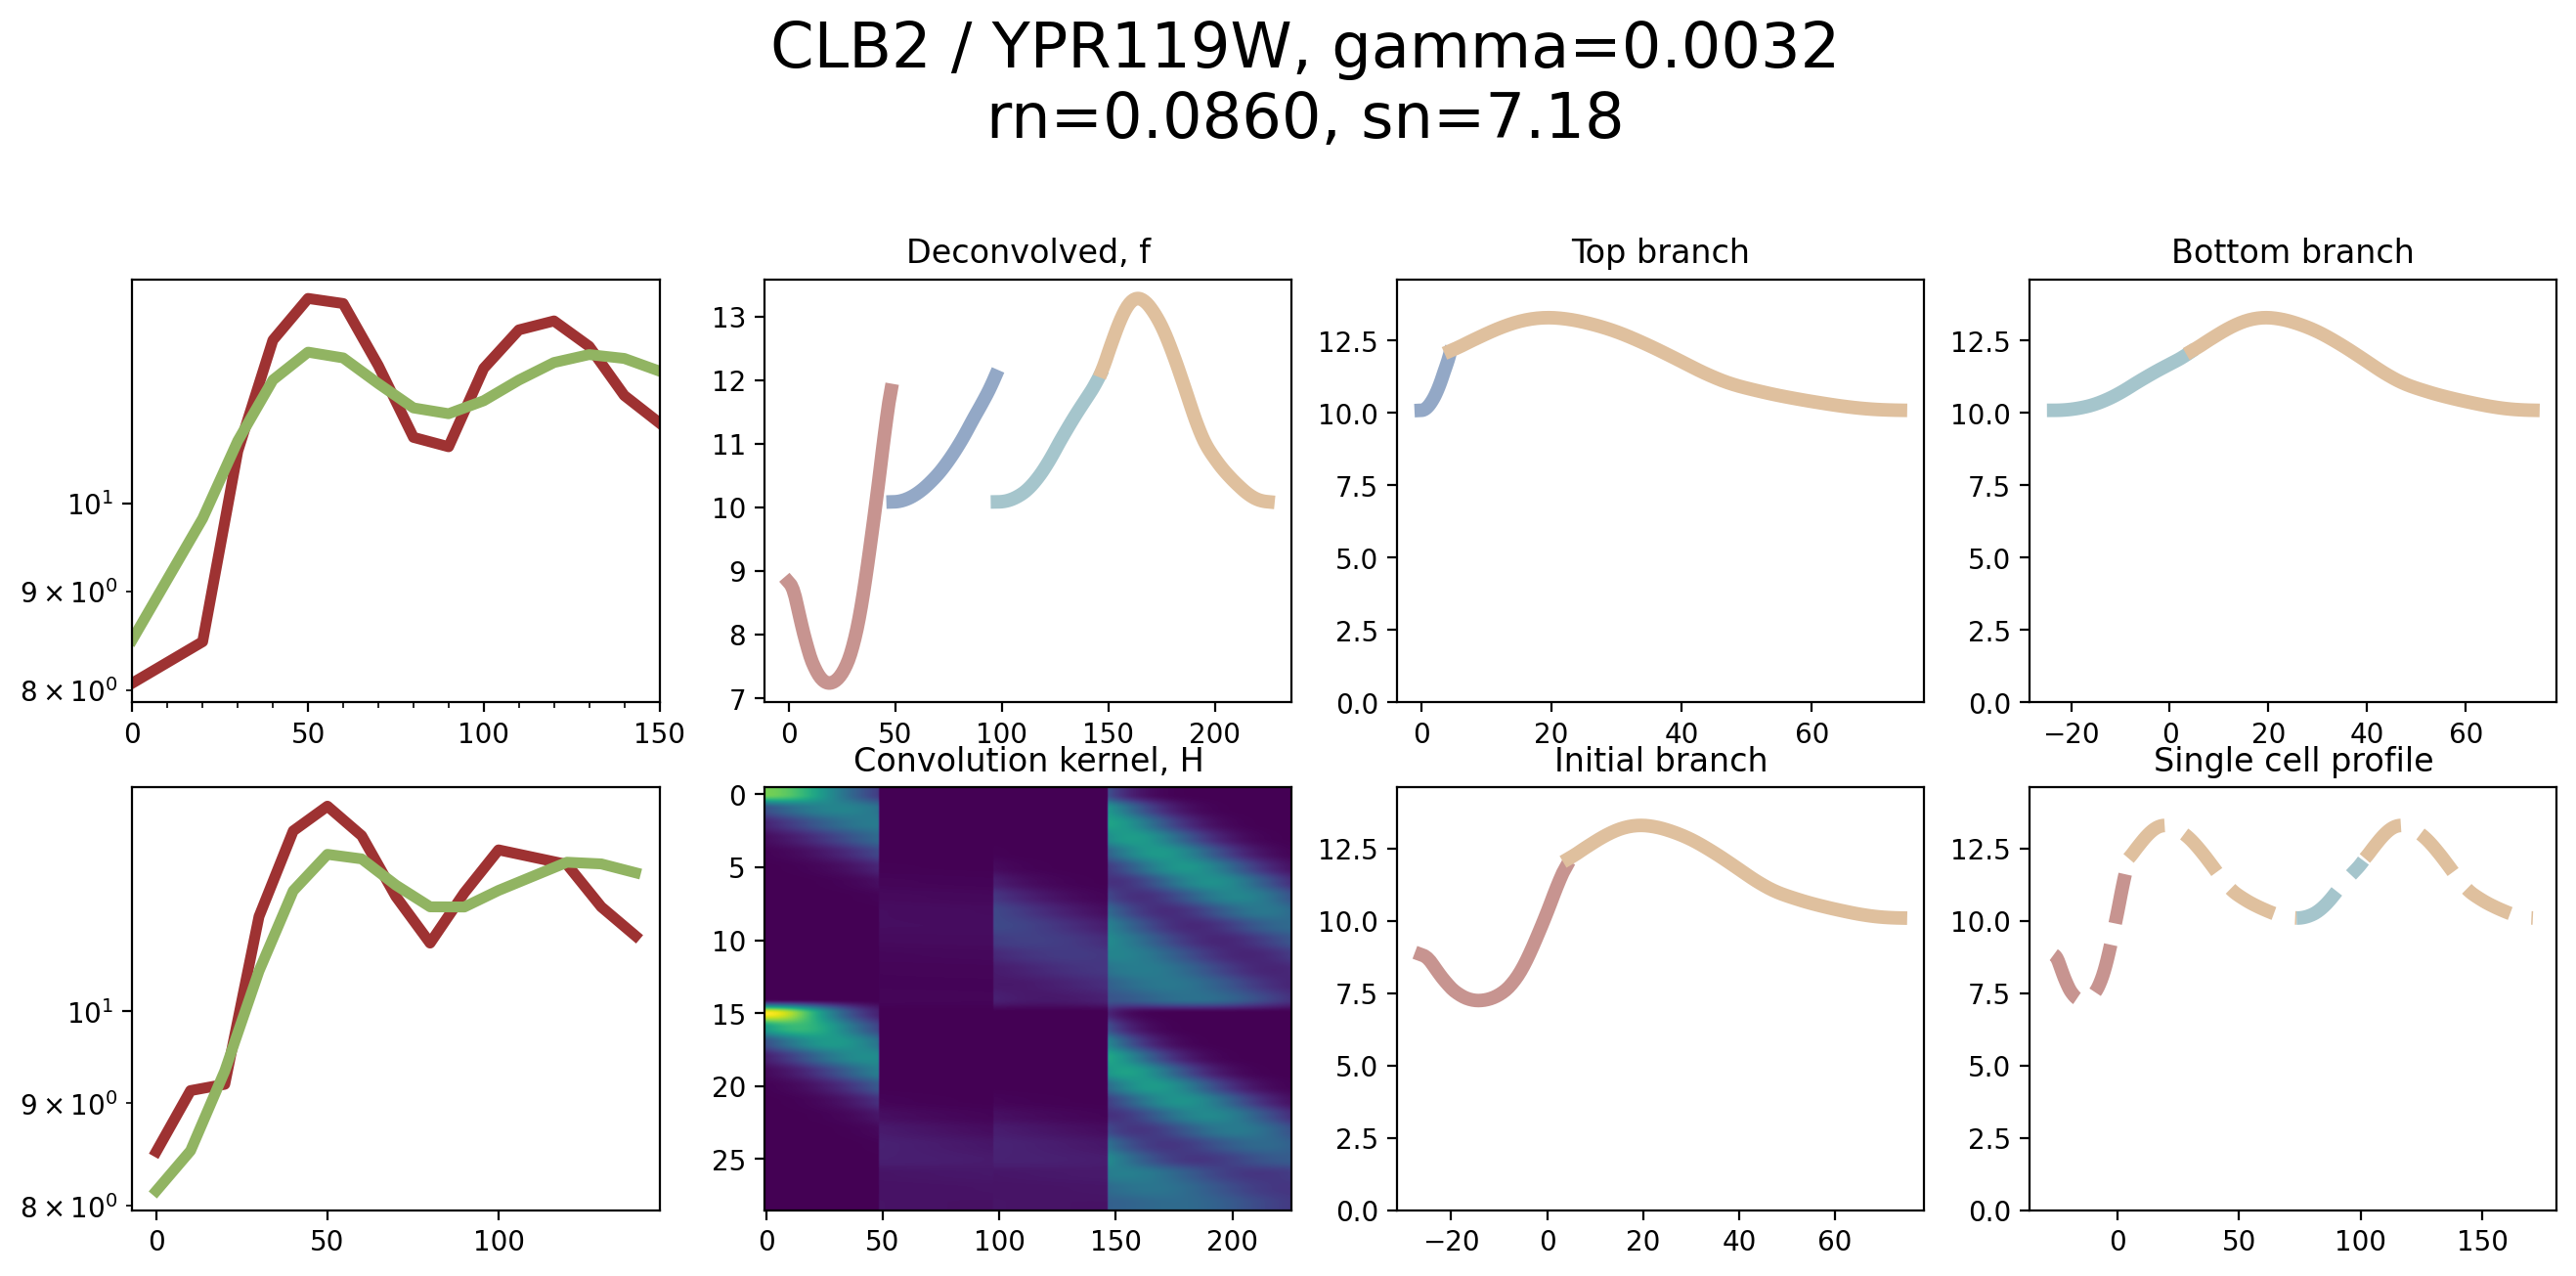

In [56]:
from src.find_gamma import FindOptimalGamma

vst_config = load_combined_yl_vst_gene_expression_config()
vst_model = Model(config=vst_config, gamma=0.004, gene_or_orfname='CLB2')
vst_model.deconvolve()

try:
    find_gamma = FindOptimalGamma(vst_model)
    find_gamma.find_optimal()
except UnboundLocalError:
    vst_model.deconvolve()
          
vst_model.plot_deconvolved_gene()